In [3]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field


In [4]:
load_dotenv()

True

In [5]:
model = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [47]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive","negative"] = Field(description="The sentiment of the text")

In [10]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [11]:
structuredModel1=model.with_structured_output(SentimentSchema)
structuredModel2=model.with_structured_output(DiagnosisSchema)

In [54]:
prompt="i love this product!"
structuredModel1.invoke(prompt).sentiment

'positive'

In [55]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal['posititve','negative']
    diagnosis:dict
    response:str

In [59]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structuredModel1.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive", "diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive'
    else:
        return 'diagnosis'
    
def positive(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

def diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structuredModel2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}

In [60]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive', positive)
graph.add_node('diagnosis', diagnosis)
graph.add_node('negative', negative)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive', END)

graph.add_edge('negative', 'diagnosis')
graph.add_edge('diagnosis', END)

workflow = graph.compile()

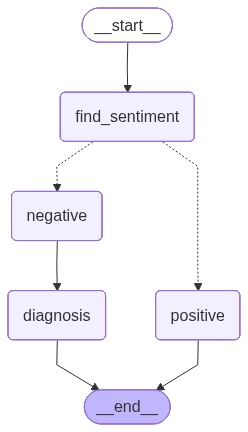

In [32]:
workflow

In [61]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'}}